In [2]:
!pip install -U "langchain[google-genai]"

In [1]:
!pip install -U langgraph langsmith

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.8/367.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.4/441.4 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 28.7 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.4.1
    Uninstalling langsmith-0.4.1:
      Successfully uninstalled langsmith-0.4.1
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.66
    Uninstalling langchain-core-0.3.66:
      Successfully uninstalled langchain-core-0.3.66


In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [7]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = (__import__('sys').path.insert(0, '..') or __import__('config').GOOGLE_API_KEY)

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [10]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


In [11]:
graph_builder.add_node("chatbot", chatbot)

In [12]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [13]:
graph = graph_builder.compile()

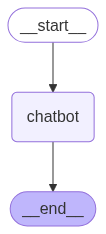

In [14]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [74]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: hi how are you
Assistant: Hi there! I'm doing well, thank you for asking.

How are you doing today?
User: what are you doing today
Assistant: As an AI, I don't have a "today" in the human sense, nor do I have personal plans or activities.

My "doing" involves continuously processing information, learning from data, and interacting with users like you by answering questions and generating text.

So, right now, I'm focused on our conversation!

What about you? What are you up to today?
User: exit
Goodbye!


In [ ]:
from IPython import

In [78]:
# user_input = input("User: ")
# if user_input.lower() in ["quit", "exit", "q"]:
#     print("Byeee!")

# result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
# result
# for message in result['messages']:
#   message.pretty_print()

User: hi
================================ Human Message =================================

hi
================================== Ai Message ==================================

Hi there! How can I help you today?


In [55]:
# user_input = input("User: ")
# if user_input.lower() in ["quit", "exit", "q"]:
#     print("Byeee!")

User: hi


In [56]:
# result = graph.stream({"messages": [{"role": "user", "content": user_input}]})

In [73]:
# result = graph.stream({"messages": [{"role": "user", "content": user_input}]})
# for event in result:
#   print(event)
#   # for value in event.values():
#   #     print("Assistant:", value["messages"][-1].content)

{'chatbot': {'messages': [AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--a472acb7-d518-4168-9724-357020de4d4f-0', usage_metadata={'input_tokens': 2, 'output_tokens': 37, 'total_tokens': 39, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}})]}}
